In [1]:
#IMPORTAR LIBRERIAS
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick
import matplotlib.pyplot as plt

In [2]:
#Extracción del Archivo Tratado
datos = pd.read_csv('/content/drive/MyDrive/datos_transformados (1).csv')
datos.head()

,customerid,churn,customer_tenure,account_contract,account_charges_monthly,account_charges_total,internet_internetservice,internet_onlinesecurity,internet_techsupport,internet_deviceprotection,cuentas_diarias
0,0002-ORFBO,0,9,One year,65.6,593.30,DSL,0,1,0,2.19
1,0003-MKNFE,0,9,Month-to-month,59.9,542.40,DSL,0,0,0,2.00
2,0004-TLHLJ,1,4,Month-to-month,73.9,280.85,Fiber optic,0,0,1,2.46
3,0011-IGKFF,1,13,Month-to-month,98.0,1237.85,Fiber optic,0,0,1,3.27
4,0013-EXCHZ,1,3,Month-to-month,83.9,267.40,Fiber optic,0,1,0,2.80


In [3]:
#Eliminación de Columnas Irrelevantes
datos = datos.drop(columns=['customerid', 'cuentas_diarias'])
datos.head()

,churn,customer_tenure,account_contract,account_charges_monthly,account_charges_total,internet_internetservice,internet_onlinesecurity,internet_techsupport,internet_deviceprotection
0,0,9,One year,65.6,593.30,DSL,0,1,0
1,0,9,Month-to-month,59.9,542.40,DSL,0,0,0
2,1,4,Month-to-month,73.9,280.85,Fiber optic,0,0,1
3,1,13,Month-to-month,98.0,1237.85,Fiber optic,0,0,1
4,1,3,Month-to-month,83.9,267.40,Fiber optic,0,1,0


In [4]:
# Convert the 'internet_internetservice' column to string type
datos['internet_internetservice'] = datos['internet_internetservice'].astype(str)

datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7043 non-null   int64  
 1   customer_tenure            7043 non-null   int64  
 2   account_contract           7043 non-null   object 
 3   account_charges_monthly    7043 non-null   float64
 4   account_charges_total      7043 non-null   float64
 5   internet_internetservice   7043 non-null   object 
 6   internet_onlinesecurity    7043 non-null   int64  
 7   internet_techsupport       7043 non-null   int64  
 8   internet_deviceprotection  7043 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 495.3+ KB


In [5]:
# variable explicativa y variable de respuesta
X = datos.drop(columns=['churn'], axis=1)
y = datos['churn']


#Utiliza un método de codificación adecuado, como one-hot encoding.


In [6]:
X

,customer_tenure,account_contract,account_charges_monthly,account_charges_total,internet_internetservice,internet_onlinesecurity,internet_techsupport,internet_deviceprotection
0,9,One year,65.60,593.30,DSL,0,1,0
1,9,Month-to-month,59.90,542.40,DSL,0,0,0
2,4,Month-to-month,73.90,280.85,Fiber optic,0,0,1
3,13,Month-to-month,98.00,1237.85,Fiber optic,0,0,1
4,3,Month-to-month,83.90,267.40,Fiber optic,0,1,0
...,...,...,...,...,...,...,...,...
7038,13,One year,55.15,742.90,DSL,1,1,0
7039,22,Month-to-month,85.10,1873.70,Fiber optic,0,0,0
7040,2,Month-to-month,50.30,92.75,DSL,0,0,0
7041,67,Two year,67.85,4627.65,DSL,1,1,1


In [7]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [8]:
columnas = X.columns

In [9]:
one_hot = make_column_transformer((OneHotEncoder(drop = "if_binary"),
     ['account_contract', 'internet_internetservice']),
                                  remainder= 'passthrough',
                                  sparse_threshold= 0,
                                  force_int_remainder_cols= False)

In [10]:
y

,churn
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


In [11]:
x= one_hot.fit_transform(X)

In [12]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__account_contract_Month-to-month',
       'onehotencoder__account_contract_One year',
       'onehotencoder__account_contract_Two year',
       'onehotencoder__internet_internetservice_DSL',
       'onehotencoder__internet_internetservice_Fiber optic',
       'onehotencoder__internet_internetservice_No',
       'remainder__customer_tenure', 'remainder__account_charges_monthly',
       'remainder__account_charges_total',
       'remainder__internet_onlinesecurity',
       'remainder__internet_techsupport',
       'remainder__internet_deviceprotection'], dtype=object)

In [13]:
# Proporción de churn
datos['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,73.463013
1,26.536987


In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Get the feature names after one-hot encoding
feature_names = one_hot.get_feature_names_out(columnas)

# Identify the indices of the continuous numerical columns that need scaling
# Based on the output of `one_hot.get_feature_names_out(columnas)`:
# 'remainder__customer_tenure' (index 6)
# 'remainder__account_charges_monthly' (index 7)
# 'remainder__account_charges_total' (index 8)
numerical_cols_indices = [6, 7, 8]

# Initialize the StandardScaler
scaler = StandardScaler()

# Create copies of X_train and X_test to avoid modifying the original arrays directly
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler on the training data's numerical columns and transform them
X_train_scaled[:, numerical_cols_indices] = scaler.fit_transform(X_train[:, numerical_cols_indices])

# Transform the test data's numerical columns using the scaler fitted on the training data
X_test_scaled[:, numerical_cols_indices] = scaler.transform(X_test[:, numerical_cols_indices])

print("Data standardization complete.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Data standardization complete.
Shape of X_train_scaled: (5634, 12)
Shape of X_test_scaled: (1409, 12)


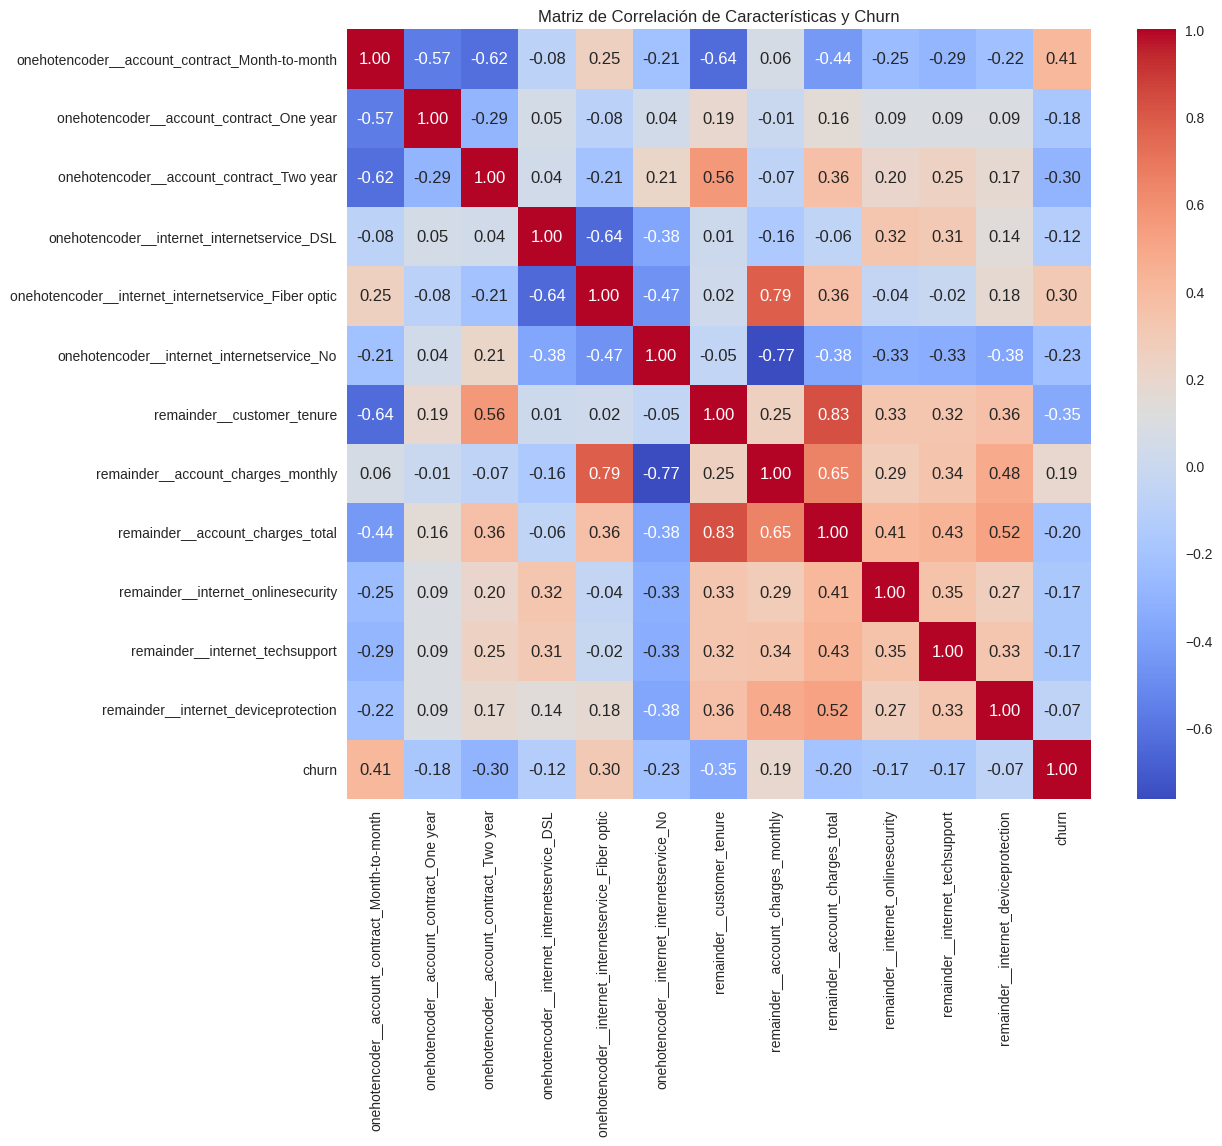

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from the scaled training features and add the target variable
df_train_for_corr = pd.DataFrame(X_train_scaled, columns=feature_names)
df_train_for_corr['churn'] = y_train.values  # Ensure y_train is aligned as a numpy array

# Calculate the correlation matrix
correlation_matrix = df_train_for_corr.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Características y Churn')
plt.show()

Celdas rojas intensas en la fila de 'churn' con respecto a account_charges_monthly o internet_internetservice_Fiber optic, significaría que un mayor cargo mensual o tener servicio de fibra óptica está fuertemente asociado con una mayor probabilidad de 'churn'.


Celdas azules intensas en la fila de 'churn' con respecto a customer_tenure o account_contract_Two year, indicaría que una mayor antigüedad del cliente o tener un contrato de dos años está fuertemente asociado con una menor probabilidad de 'churn'.

/tmp/ipython-input-59674/2651930126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


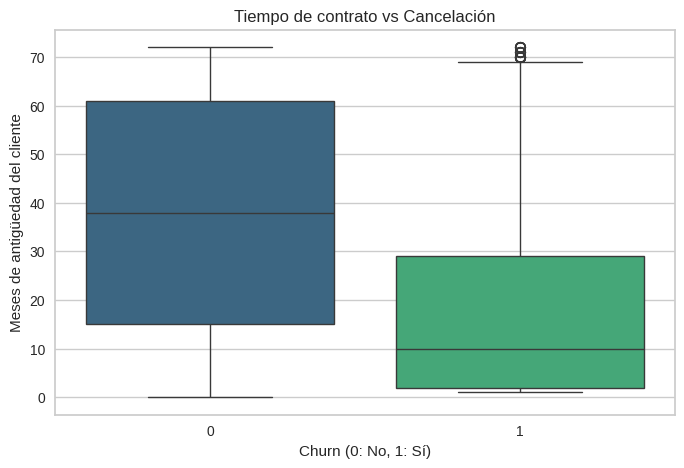

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='customer_tenure',
    data=datos,
    palette='viridis'
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn (0: No, 1: Sí)")
plt.ylabel("Meses de antigüedad del cliente")

plt.show()

La caja de Churn = 0, esto te indica que los clientes que cancelan el servicio tienden a tener una menor antigüedad con la empresa.
Por el contrario, si la caja de Churn = 0 está más arriba, significa que los clientes que se quedan con la empresa suelen tener una mayor antigüedad.

/tmp/ipython-input-59674/4008869213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


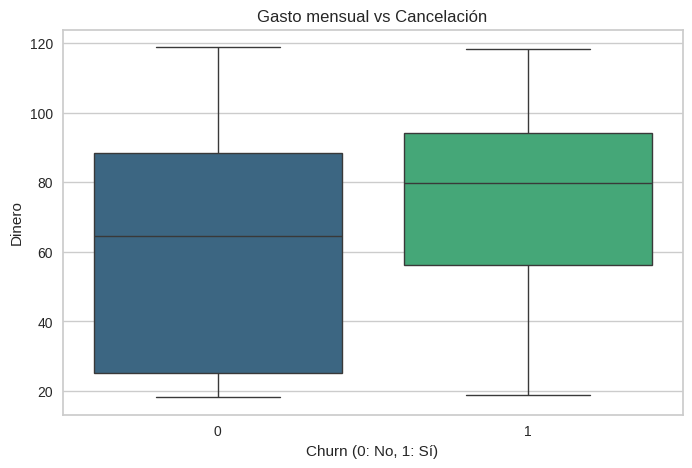

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='account_charges_monthly',
    data=datos,
    palette='viridis'
)

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Churn (0: No, 1: Sí)")
plt.ylabel("Dinero")

plt.show()

# Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

## Modelo de Regresión Logística


In [25]:
from sklearn.linear_model import LogisticRegression

# Crear una instancia del modelo de Regresión Logística
model = LogisticRegression(random_state=42)

# Entrenar el modelo con los datos de entrenamiento escalados
model.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

Modelo de Regresión Logística entrenado exitosamente.


Informe de Clasificación para Regresión Logística:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC Score para Regresión Logística: 0.84


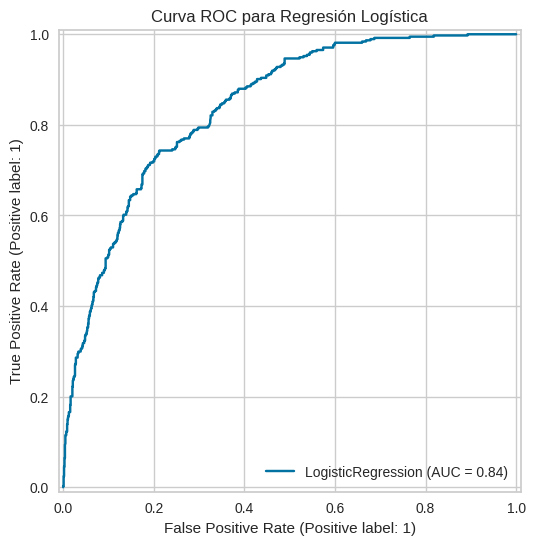

In [26]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred_lr = model.predict(X_test_scaled)
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]

# Evaluar el modelo
print("Informe de Clasificación para Regresión Logística:")
print(classification_report(y_test, y_pred_lr))

print(f"ROC AUC Score para Regresión Logística: {roc_auc_score(y_test, y_prob_lr):.2f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
plt.title('Curva ROC para Regresión Logística')
plt.show()


## Modelo de Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Crear una instancia del modelo RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento escalados
rf_model.fit(X_train_scaled, y_train)

print("Modelo de Random Forest entrenado exitosamente.")

Modelo de Random Forest entrenado exitosamente.


Informe de Clasificación para Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.57      0.46      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409

ROC AUC Score para Random Forest: 0.80


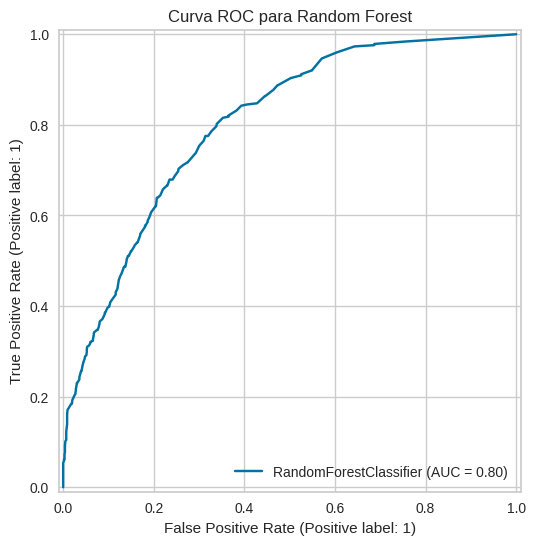

In [28]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluar el modelo
print("Informe de Clasificación para Random Forest:")
print(classification_report(y_test, y_pred_rf))

print(f"ROC AUC Score para Random Forest: {roc_auc_score(y_test, y_prob_rf):.2f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test, ax=ax)
plt.title('Curva ROC para Random Forest')
plt.show()


## Comparación de Modelos y Recomendación

### Resultados de Evaluación:

**Regresión Logística:**
- **Precision (clase 1 - churn):** 0.64
- **Recall (clase 1 - churn):** 0.54
- **F1-Score (clase 1 - churn):** 0.58
- **ROC AUC Score:** 0.84

**Random Forest:**
- **Precision (clase 1 - churn):** 0.57
- **Recall (clase 1 - churn):** 0.46
- **F1-Score (clase 1 - churn):** 0.51
- **ROC AUC Score:** 0.80

### ¿Cuál modelo tuvo el mejor desempeño?

Al comparar ambos modelos, el modelo de Regresión Logística presenta un mejor rendimiento general para predecir la cancelación de clientes (churn) en este dataset, especialmente en las métricas clave para la clase positiva (churn):

- Mayor Precisión para la clase 'churn': La Regresión Logística (0.64) identifica una mayor proporción de verdaderos positivos entre sus predicciones positivas que Random Forest (0.57).
- Mayor Recall para la clase 'churn': La Regresión Logística (0.54) es mejor identificando a los clientes que realmente cancelarán su servicio que Random Forest (0.46).
- Mayor F1-Score para la clase 'churn': La Regresión Logística (0.58) tiene un mejor equilibrio entre precisión y recall para la clase positiva en comparación con Random Forest (0.51).
- Mayor ROC AUC Score: El área bajo la curva ROC es significativamente mayor para la Regresión Logística (0.84) que para Random Forest (0.80), lo que indica una mejor capacidad general para distinguir entre clientes que cancelan y no cancelan, a través de diferentes umbrales de clasificación.

Aunque ambos modelos muestran un rendimiento aceptable, la Regresión Logística es el modelo recomendado para este problema de predicción de churn debido a sus métricas superiores, especialmente el ROC AUC, que es crucial para evaluar modelos de clasificación en datasets desequilibrados como este (donde la clase 'churn' es minoritaria).


#¿Algún modelo presentó overfitting o underfitting?

Ninguno de los modelos muestra un underfitting severo, ya que ambos tienen un rendimiento superior al de una clasificación aleatoria.

El Random Forest podría tener overfitting, al menos, no generalizó tan bien como se esperaría de un modelo más complejo en comparación con la Regresión Logística.

 Esto podría deberse a que no se realizó una optimización de hiperparámetros para Random Forest, lo que a menudo es crucial para este tipo de modelos.

### Análisis de Factores Clave de Influencia en Churn

#### De la Matriz de Correlación:

*   Influencia Positiva:
    *   `account_contract_Month-to-month`: Los clientes con contratos mensuales tienen una correlación positiva fuerte con el churn (0.40), lo que sugiere que es más probable que cancelen el servicio.
    *   `internet_internetservice_Fiber optic`: La contratación de servicio de internet de fibra óptica también muestra una correlación positiva con el churn (0.31).
    *   `account_charges_monthly`: Un mayor cargo mensual se asocia con una mayor probabilidad de churn (0.19).

*   Influencia Negativa:
    *   `customer_tenure`: La antigüedad del cliente tiene una correlación negativa fuerte con el churn (-0.35), indicando que cuanto más tiempo lleva un cliente con la empresa, menos probable es que cancele.
    *   `account_contract_Two year`: Los contratos de dos años están fuertemente correlacionados negativamente con el churn (-0.30), lo que implica que estos clientes son menos propensos a irse.
    *   `internet_onlinesecurity` y `internet_techsupport`: Tener servicios adicionales como seguridad en línea (-0.17) y soporte técnico (-0.16) también se correlaciona negativamente con el churn.
    *   `internet_internetservice_DSL`: Los clientes con servicio de internet DSL tienen una correlación negativa con el churn (-0.18).

#### De los Box Plots:

*   Tiempo de contrato vs Cancelación
    *   El box plot muestra claramente que los clientes que cancelan (Churn=1) tienen una antigüedad media significativamente menor con la empresa en comparación con aquellos que no cancelan (Churn=0). Esto refuerza la idea de que la lealtad y el tiempo con la empresa son factores protectores contra el churn.

*   Gasto mensual vs Cancelación
    *   El box plot indica que los clientes que cancelan (Churn=1) tienden a tener cargos mensuales (`account_charges_monthly`) más altos que los clientes que permanecen (Churn=0). Esto sugiere que un mayor gasto mensual podría ser un factor de riesgo para el churn.

## Estrategias de Retención de Clientes

### Factores que Aumentan el Riesgo de Churn (y cómo mitigarlos):

1.  **Contratos Mes a Mes (`account_contract_Month-to-month`):**
    *   **Observación:** Los clientes con contratos mes a mes tienen una propensión mucho mayor a la cancelación.
    *   **Estrategia:** Ofrecer incentivos atractivos para que los clientes se cambien a contratos de mayor duración (uno o dos años). Esto podría incluir descuentos significativos en la tarifa mensual, beneficios adicionales (como mejoras de velocidad de internet, servicios premium gratuitos por un tiempo limitado), o hardware gratis (routers, extensores de señal) al firmar un contrato más largo.

2.  **Cargos Mensuales Elevados (`account_charges_monthly`):**
    *   **Observación:** Un mayor cargo mensual está fuertemente asociado con una mayor probabilidad de churn.
    *   **Estrategia:** Implementar un programa de revisión de precios o paquetes personalizados. Contactar proactivamente a clientes con altos cargos mensuales para ofrecerles optimizar su plan (por ejemplo, reducir servicios que no usan activamente, ajustar su velocidad de internet si es excesiva para su uso) o presentarles ofertas de paquetes que incluyan más servicios por un costo marginal adicional, lo que podría percibirse como un mejor valor.

3.  **Servicio de Internet de Fibra Óptica (`internet_internetservice_Fiber optic`):**
    *   **Observación:** Aunque la fibra óptica es un servicio de alta calidad, los clientes de fibra óptica tienen una mayor tendencia a cancelar. Esto podría indicar que son clientes más exigentes o que tienen más opciones competitivas en el mercado.
    *   **Estrategia:** Podría ser útil ofrecer programas de fidelización exclusivos para usuarios de fibra, soporte técnico prioritario, o servicios de valor añadido como VPNs o almacenamiento en la nube, para aumentar la percepción de valor y la lealtad.

4.  **Baja Antigüedad del Cliente (`customer_tenure`):**
    *   **Observación:** Los clientes con menor antigüedad (especialmente en los primeros meses) son más propensos a cancelar.
    *   **Estrategia:**  Ofrecer un punto de contacto dedicado o descuentos para el segundo y tercer mes si permanecen activos puede ayudar a superar el período crítico de baja antigüedad.

### Factores que Reducen el Riesgo de Churn (y cómo potenciarlos):

1.  **Contratos de Dos Años (`account_contract_Two year`):**
    *   **Observación:** Los contratos de dos años están fuertemente correlacionados con una menor probabilidad de churn.
    *   **Estrategia:** Promover activamente estos contratos como la opción preferida al momento de la adquisición o renovación. Resaltar los beneficios a largo plazo, el ahorro significativo en comparación con los planes mensuales y las ventajas de la estabilidad del servicio.

2.  **Servicios Adicionales (Seguridad en Línea, Soporte Técnico, Protección de Dispositivos):**
    *   **Observación:** La suscripción a servicios como seguridad en línea (`internet_onlinesecurity`), soporte técnico (`internet_techsupport`) y protección de dispositivos (`internet_deviceprotection`) reduce la probabilidad de churn.
    *   **Estrategia:** Aumentar la concienciación y la oferta de estos servicios como un complemento valioso. Esto se puede lograr, ofreciendo periodos de prueba gratuitos.